# 4g. Analyse demographic bias

Understanding bias in predictive models is a vital part of the path to deployment. Discrimination and calibration plots can look fine when prepared using pooled data, but they may conceal systematic differences across patient groups. We use MADCAP plots to evaluate discrimination and calibration, and in notebook 2c I showed how to plot those for age subgroups using stratified MADCAPs. 

When subgroup patterns diverge, though, it can be hard to work out why because more than one mechanism can produce the same plots. In this notebook, I discuss two mechanisms that may result in differences in model performance for subgroups, and suggest methodologies for investigating each. 

## Two mechanisms whereby models encode bias

**1. Case-mix / omitted-attribute divergence.** A model is faithful to the features it was trained on, but an excluded characteristic correlates with differences in who presents and how (for example a differential disease burden or different access to health services upstream of the ED). Predictions then look systematically different across groups even though the model is doing what it was asked to do. That pattern can reveal a real health inequality in case mix.

**2. Label bias.** The outcome being predicted (`is_admitted`) is a record of a human decision. If that decision varies unfairly by group for the same clinical need, a model calibrated to the label will faithfully reproduce the bias ([Obermeyer et al., 2019](https://pubmed.ncbi.nlm.nih.gov/31649194/)). Against that unfair label, MADCAP can look *well* calibrated, including within groups. 

Stratified MADCAP is especially useful for mechanism 1. Mechanism 2 is harder to identify with these plots: calibration to the recorded label can look fine while still encoding unfair decisions. Telling the two apart needs clinical and operational judgement, careful handling of sensitive attributes, and usually checks beyond a single chart family.

## Why this matters for demand prediction

In this project, admission probabilities feed bed-count distributions by hospital specialty. If a group is systematically under- or over-predicted, whether from omitted case mix or from a biased label, forecasts for the specialties those patients tend to need will be systematically off, even when overall plots on the wider patient cohort look reasonable.

## Which subgroups should we think about?

A natural starting point is attributes that shape how patients present and which specialties they need, and attributes where unequal model performance would be especially concerning.

Under the UK Equality Act 2010, **age, sex, and race (including ethnicity)** are all protected characteristics. The considerations are not the same for each:

- **Age and sex.** We expect these to affect clinical need and which services a patient is likely to use (for example paediatric versus adult pathways, or differences in admission patterns). They are routinely used as *features* in clinical prediction and appear in many standard risk scores. That said, their inclusion should always be justified in context, rather than assuming that it is fine to include them because it is standard practice. Different case mix by age does not make poor calibration for children or older adults acceptable.
- **Race and ethnicity.** We would not want race or ethnicity to determine which services a patient can access, or how their risk is scored. For bed-demand prediction specifically, once the usual clinical/operational features are included (age, acuity, location, and so on), race or ethnicity ought not to tell you anything extra about who is admitted. For this reason, so they are rarely appropriate as training features. 

Leaving ethnicity out of training is different from *monitoring* whether the model performs differently across ethnic groups. Stratifying diagnostics by ethnicity, where the data can be used appropriately, can surface unfair performance.

This notebook shows how to do this.  Any artificial ethnicity column below is used for evaluation only, and it is synthetic.

## Approach

I load data and train admission classifiers (same approach as notebook **4d**). For mechanism 1 I construct a case-mix / omitted-attribute example and use stratified MADCAP (via `patientflow.evaluate`) to inspect it. For mechanism 2 I discuss label bias: why `is_admitted` can encode unfair decisions, and what that implies for interpretation. I close with implications of going forward when subgroup patterns look wrong, then a short summary.


In [1]:
%load_ext autoreload
%autoreload 2


## Load data and train models

Use `prepare_prediction_inputs` as in notebook **4d**. Request the UCLH public extract on [Zenodo](https://zenodo.org/records/14866057), or set `data_folder_name` to `'data-synthetic'`.


In [2]:
from typing import Any
from datetime import timedelta

import pandas as pd

from patientflow.train.emergency_demand import prepare_prediction_inputs
from patientflow.prepare import create_temporal_splits

data_folder_name = "data-public"
prediction_inputs = prepare_prediction_inputs(data_folder_name, verbose=False)

admissions_models = prediction_inputs["admission_models"]
ed_visits = prediction_inputs["ed_visits"]
params = prediction_inputs["config"]

prediction_window = timedelta(minutes=params["prediction_window"])
prediction_times = params["prediction_times"]
prediction_dict = {tuple[Any, ...](pt): prediction_window for pt in prediction_times}

start_training_set = params["start_training_set"]
start_calibration_set = params["start_calibration_set"]
start_validation_set = params["start_validation_set"]
start_test_set = params["start_test_set"]
end_test_set = params["end_test_set"]

eval_split = "valid"

_, _, valid_visits_df, test_visits_df = create_temporal_splits(
    ed_visits,
    start_training_set,
    start_validation_set,
    start_test_set,
    end_test_set,
    col_name="snapshot_date",
    visit_col="visit_number",
    verbose=False,
    start_calibration=start_calibration_set,
)

eval_visits_df = valid_visits_df if eval_split == "valid" else test_visits_df
print(f"{eval_split} cohort: {len(eval_visits_df)} snapshots")
print(f"Admission models: {len(admissions_models)}")


valid cohort: 10415 snapshots
Admission models: 5


## 1. Mechanism 1: case-mix / omitted-attribute divergence

Here I demonstrate how to investigate mechanism 1. I assign each visit an **artificial ethnicity** label with different admission base rates: membership odds depend on `is_admitted`, so one label is proportionately higher among admitted patients. The classifier never saw this column, so two visits with the same clinical features get the same predicted probability regardless of artificial ethnicity, but by design, admission rates differ by group.

That is a **case-mix / omitted-attribute** illustration, not a claim about any real ethnic group, and not label bias (the admission labels themselves are left unchanged).


In [3]:
import numpy as np


def attach_artificial_ethnicity(
    visits: pd.DataFrame,
    *,
    label_col: str = "is_admitted",
    column: str = "ethnicity",
    labels: tuple[str, ...] = ("Group A", "Group B", "Group C"),
    p_given_admitted: tuple[float, ...] = (0.55, 0.30, 0.15),
    p_given_not_admitted: tuple[float, ...] = (0.20, 0.40, 0.40),
    seed: int = 42,
) -> pd.DataFrame:
    """Attach an artificial ethnicity column with different admission prevalence.

    Group A is over-represented among admitted visits relative to non-admitted
    visits, so Group A has a higher empirical admission rate. Illustration only.
    """
    if abs(sum(p_given_admitted) - 1.0) > 1e-9 or abs(sum(p_given_not_admitted) - 1.0) > 1e-9:
        raise ValueError("Probability tuples must each sum to 1")
    if len(labels) != len(p_given_admitted) or len(labels) != len(p_given_not_admitted):
        raise ValueError("labels and probability tuples must have the same length")

    out = visits.copy()
    rng = np.random.default_rng(seed)
    y = out[label_col].astype(bool).to_numpy()
    assigned = np.empty(len(out), dtype=object)
    n_pos = int(y.sum())
    n_neg = int((~y).sum())
    assigned[y] = rng.choice(labels, size=n_pos, p=p_given_admitted)
    assigned[~y] = rng.choice(labels, size=n_neg, p=p_given_not_admitted)
    out[column] = assigned
    return out


eval_visits_with_ethnicity = attach_artificial_ethnicity(eval_visits_df)

summary = (
    eval_visits_with_ethnicity.groupby("ethnicity", observed=True)["is_admitted"]
    .agg(n="size", admission_rate="mean")
    .sort_index()
)
summary


,n,admission_rate
ethnicity,,
Group A,2635,0.319924
Group B,4027,0.111994
Group C,3753,0.063682


### A worked example: checking whether a feature is a demographic proxy

Another manifestation of the same problem is a feature the model already uses that is correlated with a demographic it does not: predictions can still differ by group without ethnicity ever being an input. It is worth checking candidate features against a demographic split before reading the MADCAP charts.

We don't have real ethnicity data to check directly. But the same concern: a feature that looks operational but carries demographic signal, can be demonstrated with real columns we do have. Here we check whether `current_location_type`, which records where in the department a patient was at snapshot time, is associated with `age_group`.


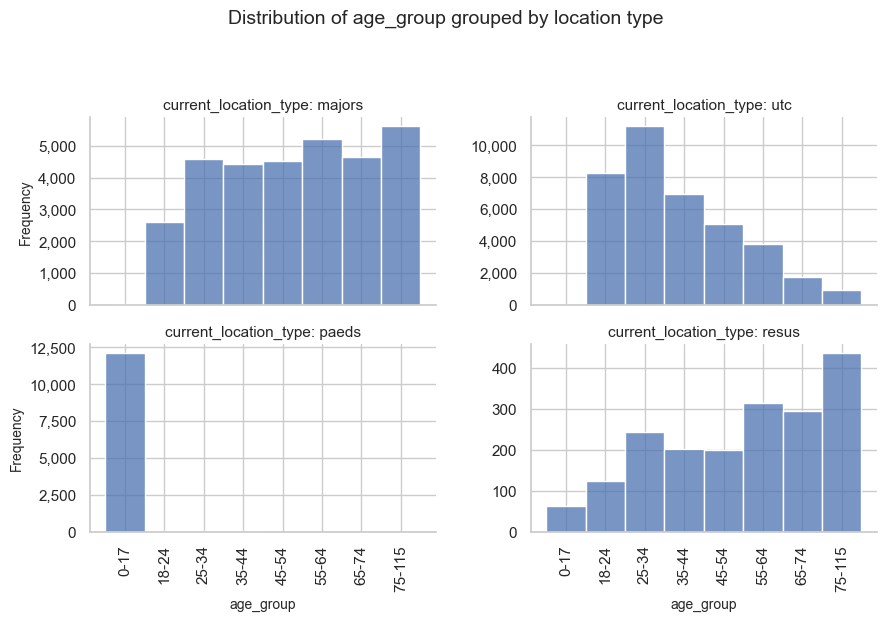

In [4]:
from patientflow.viz.data_distribution import plot_data_distribution

age_group_order = [
    "0-17",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74",
    "75-115",
]
location_order = ["majors", "utc", "paeds", "resus"]

# Age distribution within main ED locations: is location a proxy for age?
# Use the loaded visits frame (not the artificial-ethnicity eval copy).
ed_visits_main_locs = ed_visits[
    ed_visits["current_location_type"].isin(location_order)
].copy()
ed_visits_main_locs["current_location_type"] = pd.Categorical(
    ed_visits_main_locs["current_location_type"],
    categories=location_order,
    ordered=True,
)

plot_data_distribution(
    ed_visits_main_locs,
    "age_group",
    "current_location_type",
    "location type",
    plot_type="hist",
    rotate_x_labels=True,
    ordinal_order=age_group_order,
    col_wrap=2,
    sharey=False,
    show=True,
)


The table below uses the same data as the plot: each row is one location, and the values are the share of that location’s snapshots in selected age groups. I show 0–17, 18–24, 25–34 and 75+ so the paediatric pathway and the older-adult skew are easy to compare.

In [5]:
loc_age = pd.crosstab(
    ed_visits_main_locs["current_location_type"],
    ed_visits_main_locs["age_group"],
    normalize="index",
)
print(loc_age.loc[location_order, ["0-17", "18-24", "25-34", "75-115"]].round(3))


age_group               0-17  18-24  25-34  75-115
current_location_type                             
majors                 0.001  0.083  0.145   0.177
utc                    0.000  0.217  0.295   0.025
paeds                  0.997  0.001  0.001   0.000
resus                  0.034  0.066  0.129   0.233


Patients aged 75+ make up about 2.5% of UTC attendances but about 18% of majors and 23% of resus, despite none of those fields being an explicit age rule. One location, `paeds`, is deliberately age-restricted (a paediatric pathway); its age mix is expected and by design, not evidence of a hidden proxy. The interesting finding is that the non-paediatric locations still have different age mixes, even though none of those fields is an age rule.

The charts and table above show how the age mix varies by location. They do not tell us whether location still stands in for age once age is included as a feature in the same model.

Different mixes by location are a reason to look further, not a verdict that the model is unfair. A practical sequence is:

1. Repeat these feature-versus-group plots for other operational features that might stand in for a demographic. Use the grouping that matches the question — age here; ethnicity or another protected characteristic that is not a training feature, where that data can be used appropriately.
2. With clinicians, decide whether any association is expected routing (as with paeds) or needs explanation (older patients in majors and resus versus UTC).
3. Then use stratified MADCAP (next) to see whether predicted and observed outcomes actually diverge by group.

### Stratified MADCAP as a diagnostic for mechanism 1

One practical check for case-mix / omitted-attribute divergence is to repeat the MADCAP (Model Accuracy Diagnostic Calibration Plot) view within subgroups. Notebook **2c** did that with `plot_madcap_by_group` on age. Notebook **4d** produced the same plots as part of an evaluation run using `patientflow.evaluate`; here I use the `evaluate` package again, but this time specifying my own MADCAP groups using `MadcapGrouping`.

`MadcapGrouping` names the visit-frame column, a display label, and the output file stem. When `madcap_groupings` is omitted, evaluate still defaults to age subgroup plots(`madcap_by_age.png`). Here I request MADCAP by age, sex, and the artificial ethnicity column. The ethnicity column is on the visit frame for those charts only; it is not a model input.




In [6]:
from pathlib import Path

from patientflow.evaluate.inputs import (
    EvaluationInputsBuilder,
    EvaluationTarget,
    MadcapGrouping,
)
from patientflow.predict.demand import FlowSelection

MADCAP_CLOCK = (6, 0)
_admission_models = (
    admissions_models.values()
    if isinstance(admissions_models, dict)
    else admissions_models
)
madcap_models = [
    m
    for m in _admission_models
    if tuple(m.training_results.prediction_time) == MADCAP_CLOCK
]
if not madcap_models:
    raise ValueError(f"No admission model for prediction_time={MADCAP_CLOCK}")

madcap_groupings = [
    MadcapGrouping("age_group", "Age group", "madcap_by_age"),
    MadcapGrouping("sex", "Sex", "madcap_by_sex"),
    MadcapGrouping("ethnicity", "Ethnicity", "madcap_by_ethnicity"),
]

evaluation_targets = [
    EvaluationTarget(
        flow_name="ed_admissions_cls",
        flow_type="admissions",
        evaluation_mode="classifier_probability_quality",
        component="classifier_probability_quality",
        observation_mode="admitted_at_some_point",
    ),
]

inputs = (
    EvaluationInputsBuilder(
        flow_selection=FlowSelection.emergency_only(),
        prediction_dict={MADCAP_CLOCK: prediction_dict[MADCAP_CLOCK]},
        eval_split=eval_split,
    )
    .with_evaluation_targets(evaluation_targets)
    .add_classifier(
        flow_name="ed_admissions_cls",
        trained_models=madcap_models,
        visits_df=eval_visits_with_ethnicity,
        label_col="is_admitted",
        madcap_groupings=madcap_groupings,
    )
    .build()
)

print("Registered MADCAP groupings:")
for g in inputs.classifier_by_flow["ed_admissions_cls"]["madcap_groupings"]:
    print(f"  {g.column!r} → {g.file_stem}.png ({g.display_name})")
print(f"Using {len(madcap_models)} model(s) at {MADCAP_CLOCK}")


Registered MADCAP groupings:
  'age_group' → madcap_by_age.png (Age group)
  'sex' → madcap_by_sex.png (Sex)
  'ethnicity' → madcap_by_ethnicity.png (Ethnicity)
Using 1 model(s) at (6, 0)


`run_evaluation` writes discrimination, overall MADCAP, one stratified MADCAP set per requested grouping, and calibration under a timestamped folder (same pattern as notebook **4d**). Here I restrict to the **06:00** classifier so the panels match the sample-size table below. The next cell runs that evaluation; the cell after plots the stratified MADCAP panels inline for reading in this notebook (without embedding the saved PNG files).


In [7]:
from datetime import datetime

from patientflow.evaluate.runner import run_evaluation

run_name = f"notebook4g_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
out = run_evaluation(
    Path("eval-output"),
    inputs,
    run_name=run_name,
    charts="all",
    training_metadata={
        "start_training_set": str(start_training_set),
        "start_validation_set": str(start_validation_set),
        "start_test_set": str(start_test_set),
        "end_test_set": str(end_test_set),
    },
)
cls_dir = out["run_dir"] / "classifiers" / "ed_admissions_cls"
print(f"Evaluation artefacts in {out['run_dir']}")


Evaluation artefacts in eval-output/notebook4g_20260806_182708


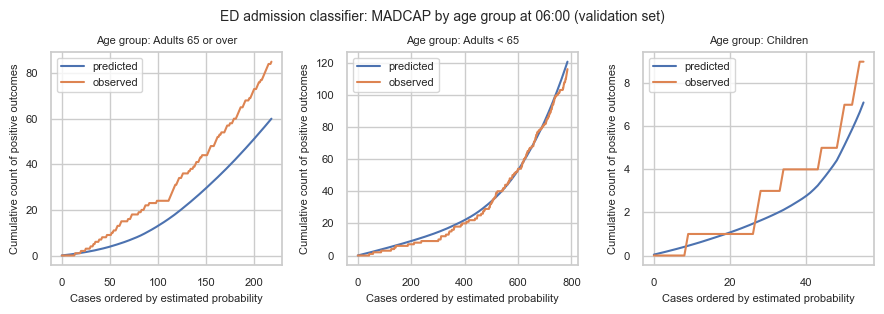

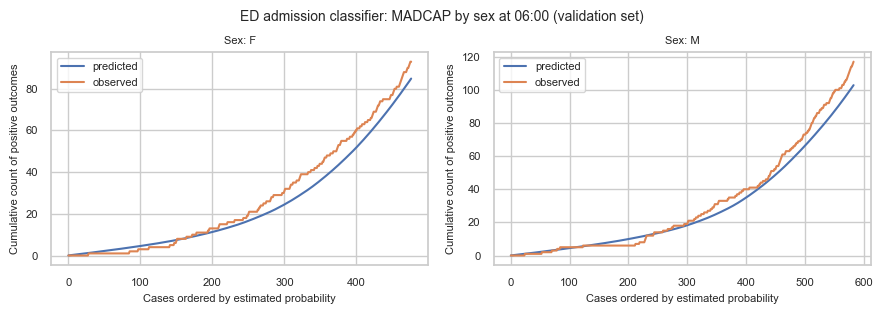

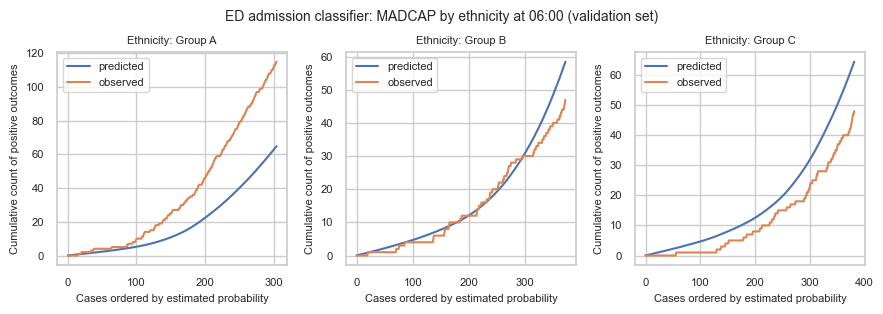

In [8]:
from patientflow.viz.madcap import plot_madcap_by_group

split_label = "validation set" if eval_split == "valid" else f"{eval_split} set"
clock_label = f"{MADCAP_CLOCK[0]:02d}:{MADCAP_CLOCK[1]:02d}"

for grouping in madcap_groupings:
    plot_madcap_by_group(
        madcap_models,
        eval_visits_with_ethnicity,
        grouping_var=grouping.column,
        grouping_var_name=grouping.display_name,
        label_col="is_admitted",
        show=True,
        suptitle=(
            f"ED admission classifier: MADCAP by {grouping.display_name.lower()} "
            f"at {clock_label} ({split_label})"
        ),
    )


On the **ethnicity** panels, the results are as designed. Group A was given a higher admission prevalence while predictions ignore ethnicity, so a different relationship between cumulative predicted and observed outcomes than in Groups B and C is what we would expect.

On the **age** panels, predicted and observed track well for adults under 65. For adults 65 or over, more patients were admitted than the model expected. That is the same group that, in the location check, is much more often in majors and resus than in UTC, so this panel reflects a different mix of ED pathways. 

We need to be careful about over-interpretation. We have not shown that the shortfall of predicted versus observed admissions among adults 65 or over is explained by their different mix of ED locations. We have shown two separate facts:

* older patients are much more often in majors and resus than in UTC
* on the 06:00 MADCAP, adults 65 or over have fewer predicted admissions than were observed

### How large does a subgroup panel need to be?

Calibration assessments are unstable with the groups being evaluated are small. Work on minimum sample sizes for validating clinical prediction models ([Riley et al., 2021](https://doi.org/10.1002/sim.9025)) suggests calibration assessment needs at least ~100 outcome events in the group being evaluated, and the same paper notes that subgroup-level calibration typically needs more than this floor. So **~100 events** is a lower bound for a single validation cohort. For stratified charts, either aim substantially higher per panel before treating the plot as decisive (for example on the order of 200+ admissions), which may mean you have to widen the evaluation window until thin groups accumulate enough events, or treat panels that only clear ~100 events as exploratory, useful for hypothesis generation, not as a green light.


In [9]:
# Cited floor for a validation cohort; too low to treat as enough per subgroup panel.
MIN_EVENTS_FLOOR = 100
# Illustrative stricter target for reading a stratified MADCAP panel as more than exploratory.
MIN_EVENTS_PANEL = 200
MADCAP_CLOCK = (6, 0)

from patientflow.prepare import prepare_patient_snapshots
from patientflow.viz.madcap import classify_age

X_clock, y_clock = prepare_patient_snapshots(
    eval_visits_with_ethnicity,
    prediction_time=MADCAP_CLOCK,
    single_snapshot_per_visit=False,
    label_col="is_admitted",
)
clock_df = X_clock.assign(is_admitted=y_clock)
clock_df["age_band"] = clock_df["age_group"].apply(classify_age)

panel_frames = []
for group_col, label in (
    ("ethnicity", "ethnicity"),
    ("age_band", "age"),
    ("sex", "sex"),
):
    panel = (
        clock_df.groupby(group_col, observed=True)["is_admitted"]
        .agg(n_visits="size", n_admissions="sum", admission_rate="mean")
        .reset_index()
        .rename(columns={group_col: "subgroup"})
    )
    panel.insert(0, "grouping", label)
    panel_frames.append(panel)

panel_n = pd.concat(panel_frames, ignore_index=True)
panel_n.insert(0, "prediction_time", [MADCAP_CLOCK] * len(panel_n))
panel_n["visits_for_floor"] = (
    MIN_EVENTS_FLOOR / panel_n["admission_rate"]
).round().astype(int)
panel_n["visits_for_panel_target"] = (
    MIN_EVENTS_PANEL / panel_n["admission_rate"]
).round().astype(int)
panel_n["clears_floor"] = panel_n["n_admissions"] >= MIN_EVENTS_FLOOR
panel_n["clears_panel_target"] = panel_n["n_admissions"] >= MIN_EVENTS_PANEL
panel_n


,prediction_time,grouping,subgroup,n_visits,n_admissions,admission_rate,visits_for_floor,visits_for_panel_target,clears_floor,clears_panel_target
0,"(6, 0)",ethnicity,Group A,305,115,0.377049,265,530,True,False
1,"(6, 0)",ethnicity,Group B,374,47,0.125668,796,1591,False,False
2,"(6, 0)",ethnicity,Group C,382,48,0.125654,796,1592,False,False
3,"(6, 0)",age,Adults 65 or over,219,85,0.388128,258,515,False,False
4,"(6, 0)",age,Adults < 65,786,116,0.147583,678,1355,True,False
5,"(6, 0)",age,Children,56,9,0.160714,622,1244,False,False
6,"(6, 0)",sex,F,477,93,0.194969,513,1026,False,False
7,"(6, 0)",sex,M,584,117,0.200342,499,998,True,False


At 06:00 none of the ethnicity panels reach the stricter ~200-admission target. **Group A** clears the ~100-event floor (about 115 admissions), so the large predicted-versus-observed gap is worth taking seriously as an exploratory signal, but not as a definitive calibration audit. **Groups B and C** have only about 50 admissions each: below the floor, so those panels are too thin to trust. A quiet-looking line there can be chance; a noisy one is expected.

On the real demographic charts at the same clock, **adults under 65** and **sex** panels clear the floor (and still miss the stricter target), so they are the most readable of the set. **Adults 65+** sit just under the floor (~85 admissions): treat the under-prediction pattern as suggestive, not conclusive. **Children** have only a handful of admissions: do not over-interpret that panel.


## 2. Mechanism 2: label bias

In mechanism 1 we left the admission labels as they were. We showed an omitted-attribute illustration (artificial ethnicity), a real-data check of whether an operational feature tracks a demographic (location and age), and stratified MADCAP on those groupings.

**Label bias** is different: the target `is_admitted` is itself a clinical and operational decision. If clinicians admit (or discharge) similar patients differently by group, for example underestimating severity for some patients, then the recorded label is unfair relative to true need. A well-calibrated model on that label will still reproduce the inequity: it learns to predict the biased decision, not an unbiased notion of who needed a bed.

That matters for interpretation:

- Against `is_admitted`, MADCAP can look well calibrated even when the label is unfair: the model is faithful to a biased target.
- Improving calibration to `is_admitted` does not remove label bias; it may entrench it.
- If the label looks unfair, the next step is not to add ethnicity as a feature or fit a better calibrator. It is to look at the admission decision itself, and possibly to predict a different outcome — with careful handling of sensitive attributes.


## Putting the two mechanisms together

Both mechanisms can leave hospital-wide metrics looking acceptable while some patients are poorly served. The charts and the response differ:

- **If mechanism 1 looks likely** (subgroup MADCAP diverges; the model is faithful to its features; the group difference tracks real case mix or an omitted attribute): treat the chart as a signal about who the model under- or over-serves in forecast terms. Practical next steps include checking sample size in the panel, gathering more data for thin groups, considering whether separate models or richer clinical features are justified, and being explicit with users about uncertainty for that specialty mix, not "fixing" fairness by adding ethnicity as a training feature for bed demand.
- **If mechanism 2 looks likely** (decisions look unfair for similar clinical presentations; MADCAP to `is_admitted` may still look fine): the problem is upstream of the scorer. Practical next steps sit with clinical and operational review of admission decisions, possible alternative outcome definitions closer to need, and careful handling of any use of sensitive attributes in monitoring, not tighter calibration to the biased label.

In practice the two can co-exist. Stratified MADCAP helps with mechanism 1; it will not, on its own, clear mechanism 2. Real monitoring needs real attributes (used appropriately), clinical and operational judgement, and usually checks beyond a single chart family. Patientflow stays column-agnostic: callers prescribe which columns to stratify on.


## Implications of going forward with subgroup bias

Undetected label bias is the harder problem for the checks in this notebook. The model can look well calibrated overall and within groups, including full stratified MADCAP, while systematically reproducing an unfair historical decision pattern. Because the diagnostics look clean, there is no natural trigger to go looking for it. Going live without other scrutiny can amplify existing inequities in who is admitted, even when every plot in sections 1–2 looks fine.

Subgroup diagnostics help with mechanism 1. They do not, on their own, clear mechanism 2.


## Summary

This notebook looked at two ways subgroup plots can mislead: **case-mix / omitted-attribute divergence** (mechanism 1) and **label bias** (mechanism 2).

- I attached an artificial ethnicity column with different admission rates (illustration only, not real demographics) and requested stratified MADCAP by age, sex, and that column.
- I checked whether an operational feature tracks a demographic: `current_location_type` versus `age_group`. Non-paediatric locations still have different age mixes (older patients more often in majors and resus than in UTC).
- On the 06:00 MADCAP, adults 65 or over were under-predicted. That is the same group that uses a different mix of ED locations; we have not shown that the location mix explains the shortfall.
- I set a sample-size rule for those panels (~100 admissions as a floor; ~200 before treating a panel as more than exploratory).
- For mechanism 2 I discussed why `is_admitted` can encode unfair decisions, and why calibrating to that label does not remove the inequity. This notebook does not fabricate a label-bias example on the public data.

Stratified MADCAP helps with mechanism 1; it will not, on its own, clear mechanism 2.
